# 07 SHAP Evaluation

In [10]:

from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib

## 1. Load the saved model

In [ ]:
final_model = joblib.load("../models/xgboost/v1/xgboost_behavior_shift_30.pkl")

## 2. Load data and rebuild X_test (same steps as modeling notebook)

In [12]:

DATA_PATH = Path("../data/processed/online_retail_II_labeled_30.csv")  # عدّلي الاسم حسب عندك
df = pd.read_csv(DATA_PATH)

df_sorted = df.sort_values(["CustomerID", "window_id"]).reset_index(drop=True)

TARGET_COL = "BehaviorShift"

leakage_cols = [
    "next_orders", "next_spend",
    "future_orders_change", "future_spend_change",
]
other_target_cols = [
    c for c in df_sorted.columns
    if c.startswith("BehaviorShift") and c != TARGET_COL
]
identifier_cols = [
    "CustomerID", "window_id", "window_start", "window_end",
    "first_purchase", "last_purchase",
]
drop_cols = leakage_cols + other_target_cols + identifier_cols

X = df_sorted.drop(columns=drop_cols + [TARGET_COL, "orders"], errors="ignore")  # لاحظي "orders" متشالة كمان
y = df_sorted[TARGET_COL]

split_window = df_sorted["window_id"].quantile(0.8)
train_mask = df_sorted["window_id"] < split_window
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("X_test shape:", X_test.shape)
X_test.head()

X_test shape: (3247, 22)


,spend,totalQuantity,unique_products,active_days,line_items,avargeOrderValue,items_per_order,window_days,prev_orders,prev_spend,...,prev_unique_products,prev_active_days,prev_items_per_order,orders_change_pct,spend_change_pct,totalQuantity_change_pct,avargeOrderValue_change_pct,unique_products_change_pct,active_days_change_pct,items_per_order_change_pct
5,584.91,277,22,1,22,584.91,22.0,30,1.0,382.52,...,18.0,1.0,18.0,0.000000,0.529097,0.413265,0.529097,0.222222,0.000000,0.222222
6,1294.32,676,47,1,47,1294.32,47.0,30,1.0,584.91,...,22.0,1.0,22.0,0.000000,1.212853,1.440433,1.212853,1.136364,0.000000,1.136364
14,286.25,101,17,1,17,286.25,17.0,30,3.0,345.01,...,10.0,3.0,6.0,-0.666667,-0.170314,-0.331126,1.489058,0.700000,-0.666667,1.833333
15,226.25,51,13,1,13,226.25,13.0,30,1.0,286.25,...,17.0,1.0,17.0,0.000000,-0.209607,-0.495050,-0.209607,-0.235294,0.000000,-0.235294
21,404.86,98,11,1,11,404.86,11.0,30,1.0,821.08,...,22.0,1.0,22.0,0.000000,-0.506918,-0.584746,-0.506918,-0.500000,0.000000,-0.500000


## 3-SHAP values

In [13]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

SHAP values shape: (3247, 22)
X_test shape: (3247, 22)


## 4-Summary Plot

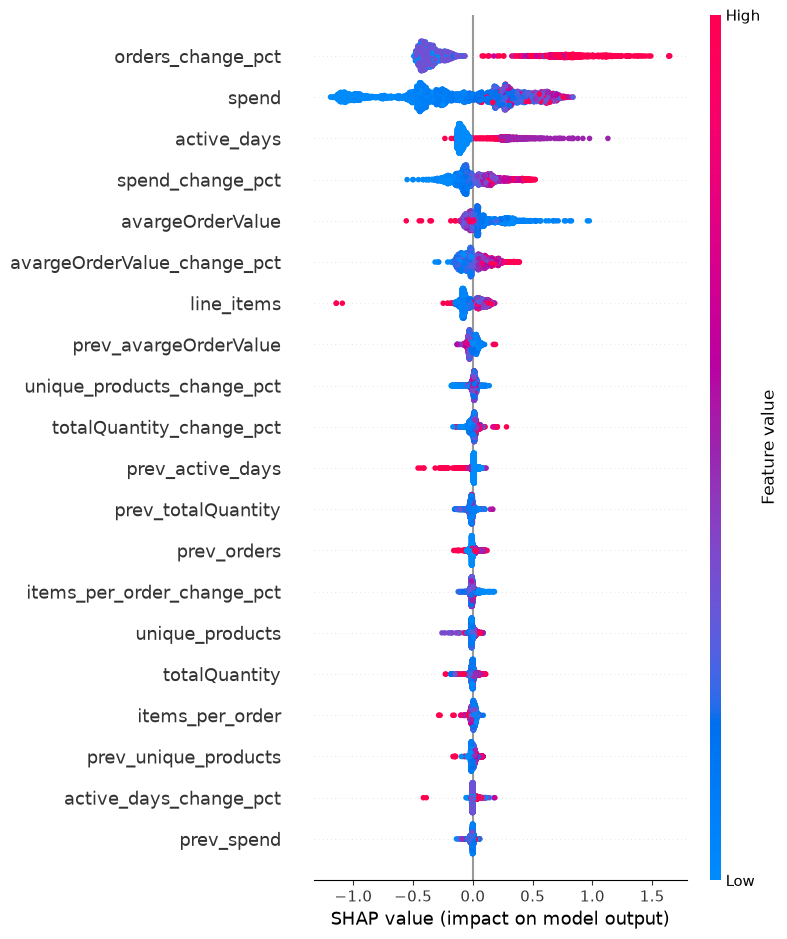

In [14]:
shap.summary_plot(shap_values, X_test)

## 5-Bar Plot

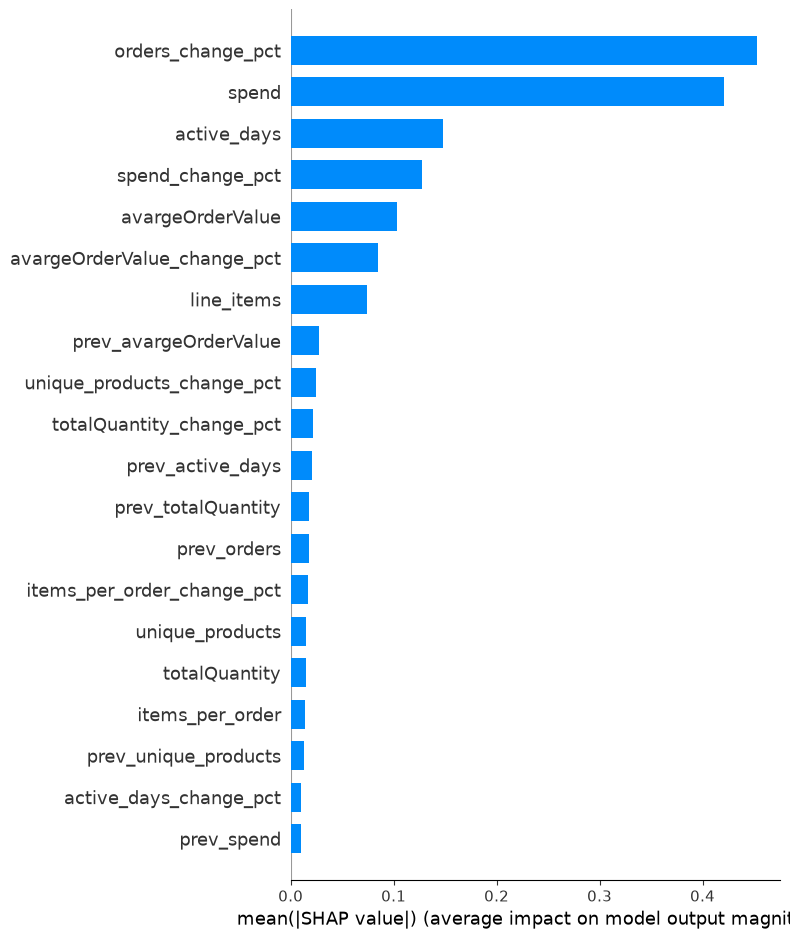

In [15]:
shap.summary_plot(shap_values, X_test, plot_type="bar")